# Paper Figures

This notebook aggregates results to generate the final figures used in the paper.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [8]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Loading Aggregated Results

We load the final CSVs generated by all the other notebooks in the pipeline.

In [39]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial import cKDTree

from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("default")

Comparison of global fidelity and boundary-local fidelity across synthetic datasets. Although globally aggregated fidelity frequently remains high, fidelity measured near teacher decision boundaries degrades substantially.

### Finalizing Paper Figures

We apply strict matplotlib formatting rules (fonts, line weights, colors) to the aggregated results to generate the final publication-ready PDFs used in the manuscript.

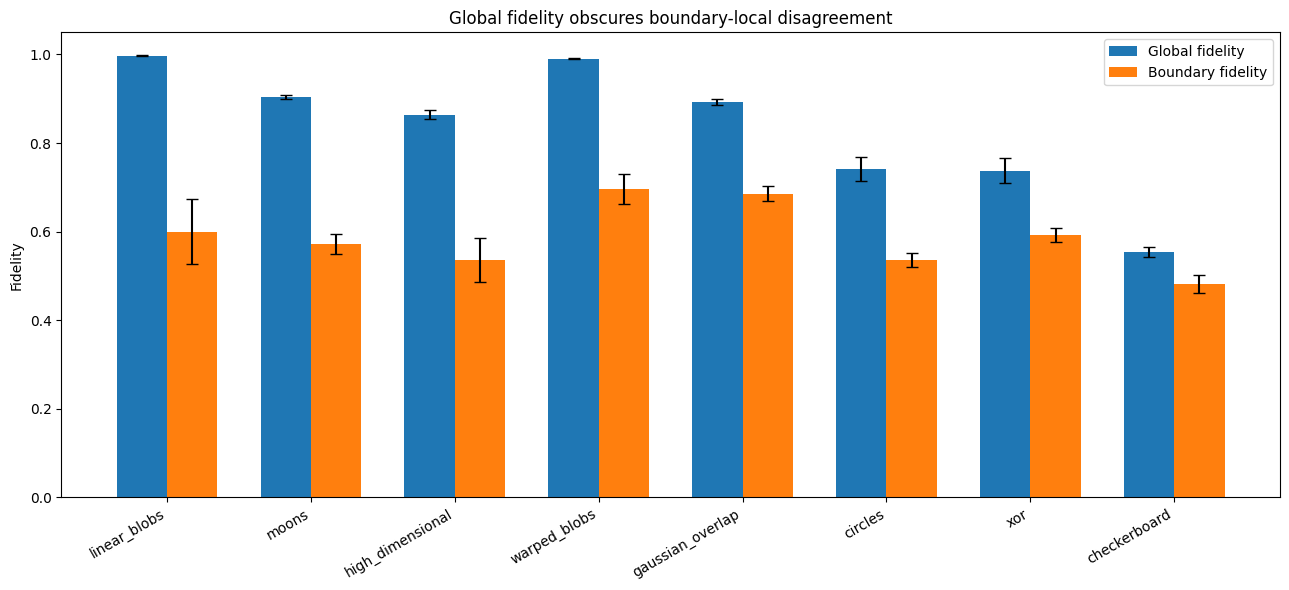

In [37]:
# Plot dataset-level global vs boundary fidelity.
dataset_summary = pd.read_csv("dataset_generalization_dataset_summary.csv", index_col=0)

ordered_datasets = dataset_summary.index.tolist()
positions = np.arange(len(ordered_datasets))
width = 0.35
n_runs = 50

global_means = [dataset_summary.loc[d, "global_fidelity_mean"] for d in ordered_datasets]
global_sems = [dataset_summary.loc[d, "global_fidelity_std"] / np.sqrt(n_runs) for d in ordered_datasets]
boundary_means = [dataset_summary.loc[d, "boundary_fidelity_mean"] for d in ordered_datasets]
boundary_sems = [dataset_summary.loc[d, "boundary_fidelity_std"] / np.sqrt(n_runs) for d in ordered_datasets]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(positions - width / 2, global_means, width, yerr=global_sems, capsize=4, label="Global fidelity")
ax.bar(positions + width / 2, boundary_means, width, yerr=boundary_sems, capsize=4, label="Boundary fidelity")
ax.set_xticks(positions)
ax.set_xticklabels(ordered_datasets, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fidelity")
ax.set_title("Global fidelity obscures boundary-local disagreement")
ax.legend()
plt.tight_layout()
plt.savefig("global_local_gap.png", dpi=300)
plt.show()


Mean gap between global fidelity and boundary-local fidelity across datasets and surrogate families. The discrepancy persists across multiple surrogate architectures, although the magnitude of the effect varies across settings.

### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

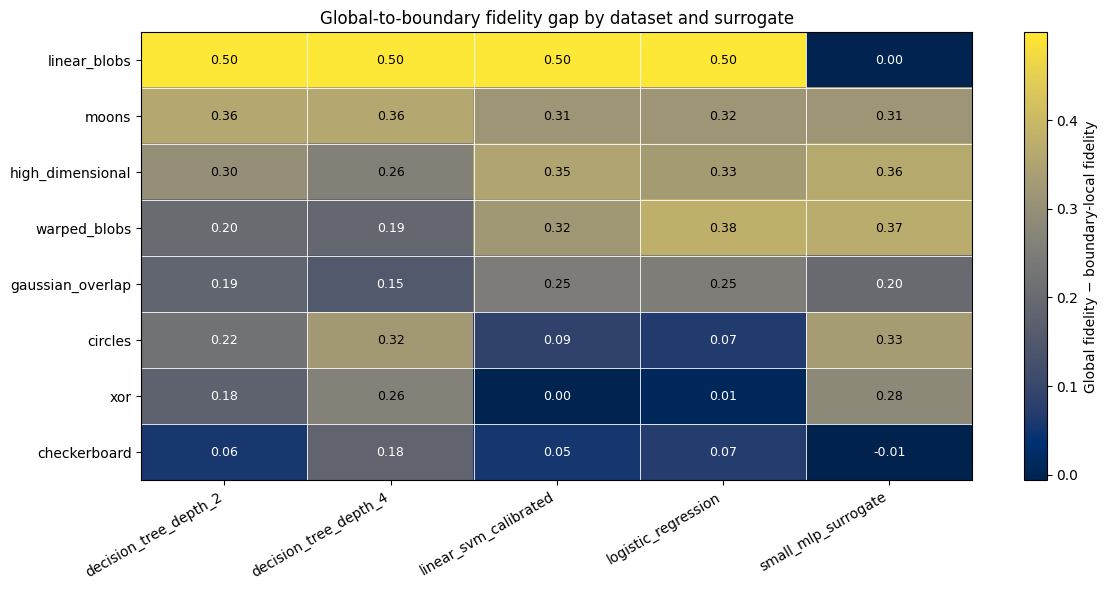

In [15]:
summary = pd.read_csv("dataset_generalization_summary_by_dataset_surrogate.csv")

gap_pivot = summary.pivot(
    index="dataset",
    columns="surrogate",
    values="boundary_gap_mean"
)
gap_pivot = gap_pivot.loc[ordered_datasets]

values = gap_pivot.values

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")

im = ax.imshow(
    values,
    aspect="auto",
    cmap="cividis"
)

ax.set_xticks(np.arange(gap_pivot.shape[1]))
ax.set_xticklabels(gap_pivot.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(gap_pivot.shape[0]))
ax.set_yticklabels(gap_pivot.index)

ax.set_title("Global-to-boundary fidelity gap by dataset and surrogate")

# Cell borders
for i in range(gap_pivot.shape[0] + 1):
    ax.axhline(i - 0.5, color="white", linewidth=0.6)

for j in range(gap_pivot.shape[1] + 1):
    ax.axvline(j - 0.5, color="white", linewidth=0.6)

# Dynamic annotation colors
threshold = np.nanmean(values)

for i in range(gap_pivot.shape[0]):
    for j in range(gap_pivot.shape[1]):
        value = values[i, j]
        display_value = 0 if abs(value) < 0.005 else value

        text_color = "white" if value < threshold else "black"

        ax.text(
            j,
            i,
            f"{display_value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Global fidelity − boundary-local fidelity")

plt.tight_layout()
plt.savefig(
    "global_local_heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

Mean fidelity across datasets is plotted for five surrogate families, and mean fraction of data elements in each bin across datasets is recorded in the bars. Across surrogate families, datasets, and seeds, fidelity shows continuous and graded behavior.

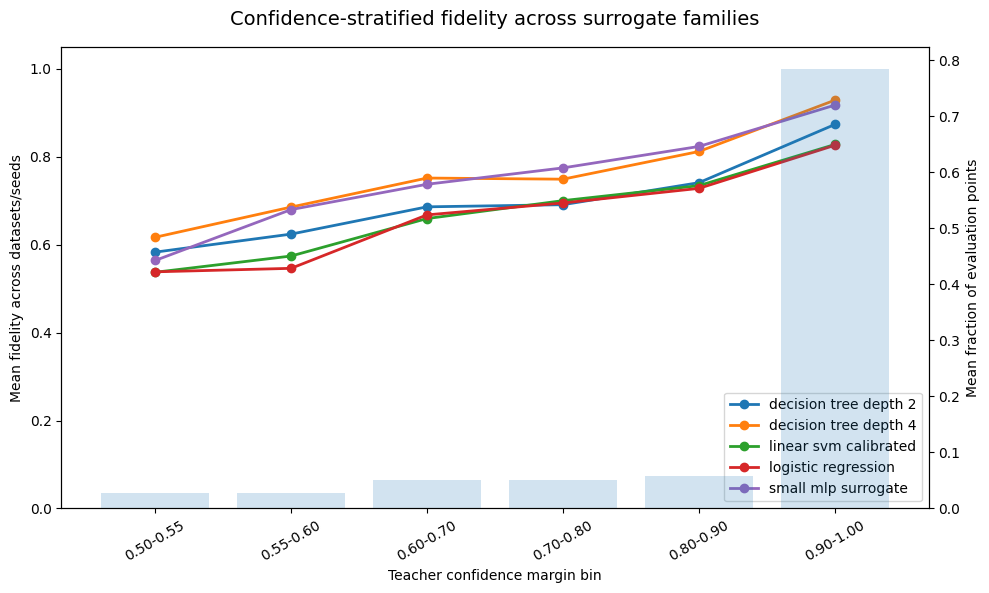

In [17]:
# Load combined summary
combined_confidence = pd.read_csv(
    "confidence_bin_fidelity_combined_summary.csv"
)

# Get shared fraction bars from first surrogate
first_surrogate = combined_confidence["surrogate"].unique()[0]
fraction_subset = combined_confidence[
    combined_confidence["surrogate"] == first_surrogate
]

fig, ax1 = plt.subplots(figsize=(10, 6), facecolor="white")
ax1.set_facecolor("white")

# Plot fidelity lines for all surrogate families
for surrogate_name in combined_confidence["surrogate"].unique():

    subset = combined_confidence[
        combined_confidence["surrogate"] == surrogate_name
    ]

    ax1.plot(
        subset["bin"],
        subset["fidelity_mean"],
        marker="o",
        linewidth=2,
        label=surrogate_name.replace("_", " "),
    )

ax1.set_ylim(0, 1.05)
ax1.set_xlabel("Teacher confidence margin bin")
ax1.set_ylabel("Mean fidelity across datasets/seeds")
ax1.tick_params(axis="x", rotation=30)

# Shared distribution bars
ax2 = ax1.twinx()

ax2.bar(
    fraction_subset["bin"],
    fraction_subset["fraction_mean"],
    alpha=0.20,
    width=0.8,
)

ax2.set_ylabel("Mean fraction of evaluation points")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(
    handles1,
    labels1,
    loc="lower right",
    frameon=True,
)

fig.suptitle(
    "Confidence-stratified fidelity across surrogate families",
    fontsize=14
)

fig.tight_layout()

plt.savefig(
    "combined_confidence_stratified_fidelity.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

todo

### Model Training

Here we initialize and train the teacher models, followed by the respective surrogate approximation models.

Using device: cpu

=== Dataset: breast_cancer ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9


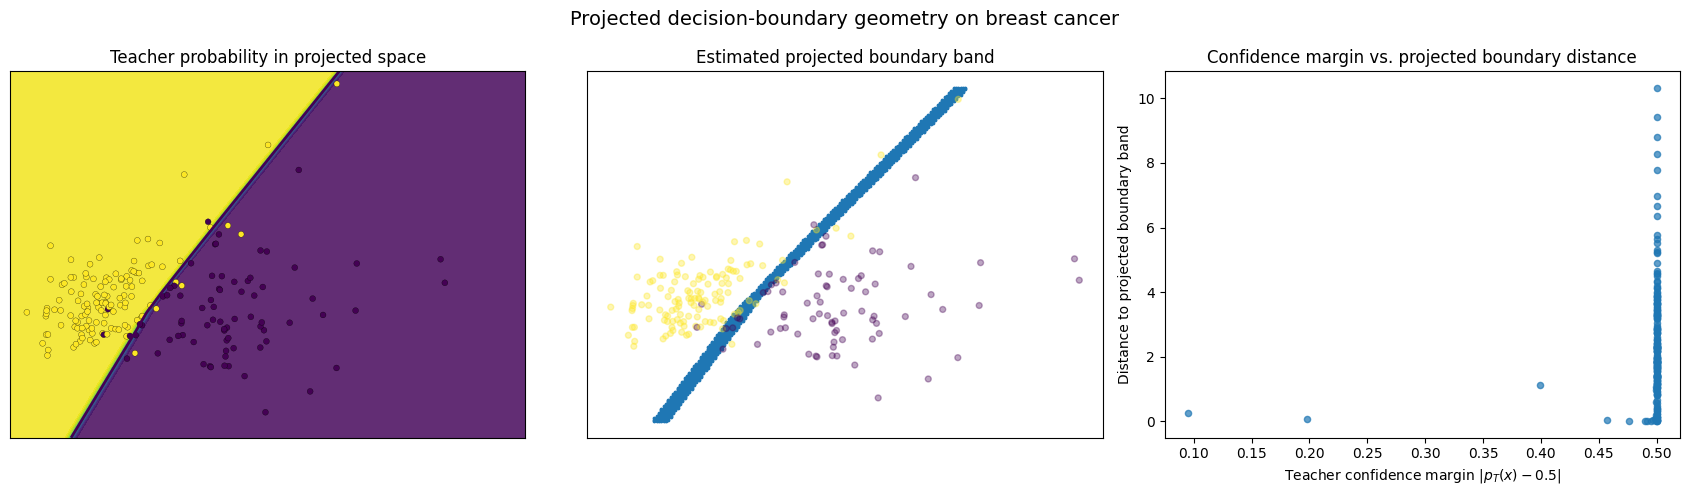

In [24]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
DEVICE = "cpu"
print("Using device:", DEVICE)

# -----------------------------------------------------------------------------
# Real-world / semi-real-world binary datasets
# -----------------------------------------------------------------------------
# Goal:
#   Show that the fidelity phenomenon is not merely an artifact of synthetic 2D
#   geometry. These are real tabular/image-feature datasets from sklearn.
#
# Datasets:
#   1. breast_cancer: real medical tabular binary classification
#   2. wine_binary: real tabular binary subset of wine classes 0 vs 1
#   3. digits_3_vs_8: real image-feature binary classification using 8x8 digits
#
# For geometry-weighted fidelity, we use a PCA projection to 2D only for
# approximate boundary geometry. The teacher/surrogate are trained on full
# standardized feature space. This intentionally tests whether the phenomenon
# survives when geometry is less directly observable.


def load_real_dataset(name):
    if name == "breast_cancer":
        data = load_breast_cancer()
        X = data.data
        y = data.target
        return X, y

    if name == "wine_binary":
        data = load_wine()
        X = data.data
        y = data.target
        mask = y < 2
        return X[mask], y[mask]

    if name == "digits_3_vs_8":
        data = load_digits()
        X = data.data
        y = data.target
        mask = (y == 3) | (y == 8)
        X = X[mask]
        y = (y[mask] == 8).astype(int)
        return X, y

    raise ValueError(f"Unknown real dataset: {name}")


# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        return torch.sigmoid(logits).cpu().numpy()


# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    """Train a surrogate to mimic the teacher's hard decisions."""
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
        model.fit(X_train, teacher_train_y)
        return model

    raise ValueError(f"Unknown surrogate: {name}")


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


# -----------------------------------------------------------------------------
# Fidelity and weighting functions
# -----------------------------------------------------------------------------

def hard_agreement(teacher_p, surrogate_p):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    return (teacher_y == surrogate_y).astype(float)


def teacher_margin(teacher_p):
    return np.abs(teacher_p - 0.5)


def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)

    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan

    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(teacher_p, alpha=10.0):
    return np.exp(-alpha * teacher_margin(teacher_p))


def geometry_weights(boundary_distances, beta=2.0):
    return np.exp(-beta * boundary_distances)

# -----------------------------------------------------------------------------
# Geometry approximation in 2D PCA space
# -----------------------------------------------------------------------------
# Important limitation:
#   This is NOT exact high-dimensional distance to the teacher boundary.
#   It is an approximate geometry probe in a 2D PCA projection.
#   That is intentional: this experiment asks whether the phenomenon survives
#   when geometry is less directly observable than in synthetic 2D data.


def fit_pca_projection(X_train, X_test):
    pca = PCA(n_components=2, random_state=42)
    Z_train = pca.fit_transform(X_train)
    Z_test = pca.transform(X_test)
    return pca, Z_train, Z_test


def make_pca_grid(Z_reference, margin=0.75, grid_size=250):
    z0_min = Z_reference[:, 0].min() - margin
    z0_max = Z_reference[:, 0].max() + margin
    z1_min = Z_reference[:, 1].min() - margin
    z1_max = Z_reference[:, 1].max() + margin

    zz0, zz1 = np.meshgrid(
        np.linspace(z0_min, z0_max, grid_size),
        np.linspace(z1_min, z1_max, grid_size),
    )
    grid_z = np.c_[zz0.ravel(), zz1.ravel()]
    return zz0, zz1, grid_z


def approximate_projected_boundary_points(
    teacher,
    pca,
    Z_reference,
    grid_size=250,
    band_eps=0.025,
    fallback_k=1500,
):
    zz0, zz1, grid_z = make_pca_grid(Z_reference, grid_size=grid_size)

    # Inverse transform PCA grid back to original standardized feature space,
    # then query the full teacher model.
    grid_x_approx = pca.inverse_transform(grid_z)
    grid_p = teacher_probs(teacher, grid_x_approx)
    margins = np.abs(grid_p - 0.5)

    boundary_points_z = grid_z[margins <= band_eps]
    used_fallback = False

    if len(boundary_points_z) < 50:
        used_fallback = True
        k = min(fallback_k, len(grid_z))
        closest_idx = np.argpartition(margins, k - 1)[:k]
        boundary_points_z = grid_z[closest_idx]

    return {
        "zz0": zz0,
        "zz1": zz1,
        "grid_z": grid_z,
        "grid_p": grid_p,
        "grid_margins": margins,
        "boundary_points_z": boundary_points_z,
        "n_boundary_points": len(boundary_points_z),
        "used_fallback": used_fallback,
    }


def nearest_projected_boundary_distances(Z_eval, boundary_points_z):
    tree = cKDTree(boundary_points_z)
    distances, _ = tree.query(Z_eval, k=1)
    return distances

# -----------------------------------------------------------------------------
# Single run
# -----------------------------------------------------------------------------

def run_one_case(dataset_name, seed, surrogate_name, alpha=10.0, beta=2.0):
    X_raw, y = load_real_dataset(dataset_name)
    X_raw = np.asarray(X_raw, dtype=float)
    y = np.asarray(y, dtype=int)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw,
        y,
        test_size=0.35,
        random_state=seed,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    teacher = train_teacher(X_train, y_train, seed=seed)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)
    teacher_test_p = teacher_probs(teacher, X_test)
    teacher_test_y = (teacher_test_p >= 0.5).astype(int)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
    surrogate_test_p = surrogate_probs(surrogate, X_test)
    surrogate_test_y = (surrogate_test_p >= 0.5).astype(int)

    pca, Z_train, Z_test = fit_pca_projection(X_train, X_test)
    Z_all = np.vstack([Z_train, Z_test])
    boundary_info = approximate_projected_boundary_points(
        teacher,
        pca,
        Z_reference=Z_all,
    )

    projected_distances = nearest_projected_boundary_distances(
        Z_test,
        boundary_info["boundary_points_z"],
    )

    agreement = hard_agreement(teacher_test_p, surrogate_test_p)
    conf_w = confidence_weights(teacher_test_p, alpha=alpha)
    geo_w = geometry_weights(projected_distances, beta=beta)
    boundary_mask = teacher_margin(teacher_test_p) <= 0.10

    global_fid = float(np.mean(agreement))
    boundary_fid = float(np.mean(agreement[boundary_mask])) if boundary_mask.sum() > 0 else np.nan
    conf_fid = normalized_weighted_average(agreement, conf_w)
    geo_fid = normalized_weighted_average(agreement, geo_w)

    corr = stats.spearmanr(teacher_margin(teacher_test_p), projected_distances).correlation

    row = {
        "dataset": dataset_name,
        "seed": seed,
        "surrogate": surrogate_name,
        "n_samples": len(X_raw),
        "n_features": X_raw.shape[1],
        "teacher_task_accuracy": accuracy_score(y_test, teacher_test_y),
        "surrogate_task_accuracy": accuracy_score(y_test, surrogate_test_y),
        "global_fidelity": global_fid,
        "boundary_fidelity": boundary_fid,
        "boundary_fraction": float(boundary_mask.mean()),
        "confidence_weighted_fidelity": conf_fid,
        "projected_geometry_weighted_fidelity": geo_fid,
        "global_minus_confidence": global_fid - conf_fid,
        "global_minus_projected_geometry": global_fid - geo_fid,
        "confidence_minus_projected_geometry": conf_fid - geo_fid,
        "margin_projected_distance_spearman": corr,
        "pca_explained_variance_ratio_sum": float(np.sum(pca.explained_variance_ratio_)),
        "n_projected_boundary_points": boundary_info["n_boundary_points"],
        "used_boundary_fallback": boundary_info["used_fallback"],
    }

    case = {
        "dataset": dataset_name,
        "seed": seed,
        "surrogate": surrogate_name,
        "X_train": X_train,
        "X_test": X_test,
        "Z_train": Z_train,
        "Z_test": Z_test,
        "y_test": y_test,
        "teacher_test_p": teacher_test_p,
        "surrogate_test_p": surrogate_test_p,
        "projected_distances": projected_distances,
        "agreement": agreement,
        "boundary_info": boundary_info,
        "pca": pca,
    }

    return row, case

# -----------------------------------------------------------------------------
# Run real-data experiment
# -----------------------------------------------------------------------------
## co-opted from my other notebook but we only need one dataset.
DATASETS = [
    "breast_cancer",
]

SURROGATES = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

SEEDS = list(range(10))

rows = []
example_cases = {}

for dataset_name in DATASETS:
    print(f"\n=== Dataset: {dataset_name} ===")
    for seed in SEEDS:
        print(f"  seed {seed}")
        for surrogate_name in SURROGATES:
            row, case = run_one_case(dataset_name, seed, surrogate_name)
            rows.append(row)
            if seed == 0 and surrogate_name == "logistic_regression":
                example_cases[dataset_name] = case

results = pd.DataFrame(rows)

# -----------------------------------------------------------------------------
# Plot: PCA geometry examples
# -----------------------------------------------------------------------------

def plot_example_case(dataset_name):
    case = example_cases[dataset_name]
    Z_test = case["Z_test"]
    y_test = case["y_test"]
    teacher_p = case["teacher_test_p"]
    distances = case["projected_distances"]
    boundary_info = case["boundary_info"]

    zz0 = boundary_info["zz0"]
    zz1 = boundary_info["zz1"]
    grid_p = boundary_info["grid_p"].reshape(zz0.shape)
    boundary_points_z = boundary_info["boundary_points_z"]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor="white")

    axes[0].contourf(zz0, zz1, grid_p, levels=30, alpha=0.85)
    axes[0].contour(zz0, zz1, grid_p, levels=[0.5], linewidths=2)
    axes[0].scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, s=18, edgecolor="k", linewidth=0.2)
    axes[0].set_title("Teacher probability in projected space")

    axes[1].scatter(boundary_points_z[:, 0], boundary_points_z[:, 1], s=3)
    axes[1].scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, s=18, alpha=0.35)
    axes[1].set_title("Estimated projected boundary band")

    axes[2].scatter(teacher_margin(teacher_p), distances, s=20, alpha=0.7)
    axes[2].set_xlabel(r"Teacher confidence margin $|p_T(x)-0.5|$")
    axes[2].set_ylabel("Distance to projected boundary band")
    axes[2].set_title("Confidence margin vs. projected boundary distance")

    for ax in axes[:2]:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle("Projected decision-boundary geometry on breast cancer", fontsize=14)
    plt.tight_layout()

    plt.savefig(
        "projected_boundary_geometry_breast_cancer.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

plot_example_case("breast_cancer")

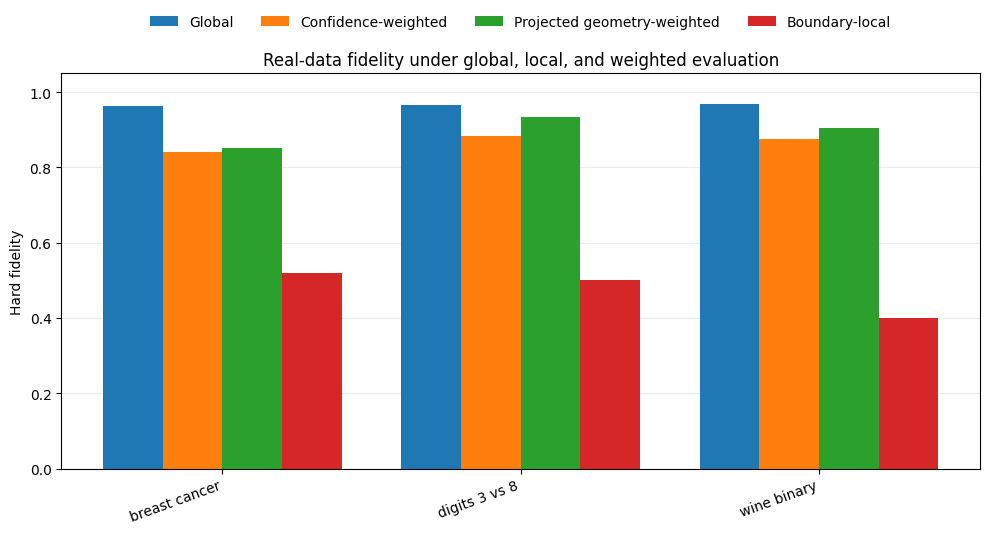

In [25]:
real_world_summary = pd.read_csv("real_world_experiment_summary.csv")

ordered = real_world_summary["dataset"].tolist()
positions = np.arange(len(ordered))
width = 0.20

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax.set_facecolor("white")

metrics = [
    ("global_fidelity_mean", "Global"),
    ("confidence_weighted_mean", "Confidence-weighted"),
    ("projected_geometry_weighted_mean", "Projected geometry-weighted"),
    ("boundary_fidelity_mean", "Boundary-local"),
]

offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

for (col, label), offset in zip(metrics, offsets):
    values = [
        real_world_summary.loc[
            real_world_summary["dataset"] == d, col
        ].iloc[0]
        for d in ordered
    ]
    ax.bar(
        positions + offset,
        values,
        width,
        label=label,
    )

ax.set_xticks(positions)
ax.set_xticklabels(
    [d.replace("_", " ") for d in ordered],
    rotation=20,
    ha="right",
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Hard fidelity")
ax.set_title("Real-data fidelity under global, local, and weighted evaluation")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=4,
    frameon=False,
)

plt.tight_layout()

plt.savefig(
    "real_world_global_boundary_weighted_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## CIFAR-10 Modern Benchmark Figures

These figures test whether the global-vs-local fidelity phenomenon persists with a ResNet18 teacher on CIFAR-10.

In [27]:
# -----------------------------------------------------------------------------
# CIFAR-10 figure utilities
# -----------------------------------------------------------------------------

def require_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing required CSV: {path}\n"
            f"Copy this CSV into the same directory as this notebook and rerun."
        )
    return pd.read_csv(path)

### CIFAR-10: Global vs Boundary-Local vs Confidence-Weighted Fidelity

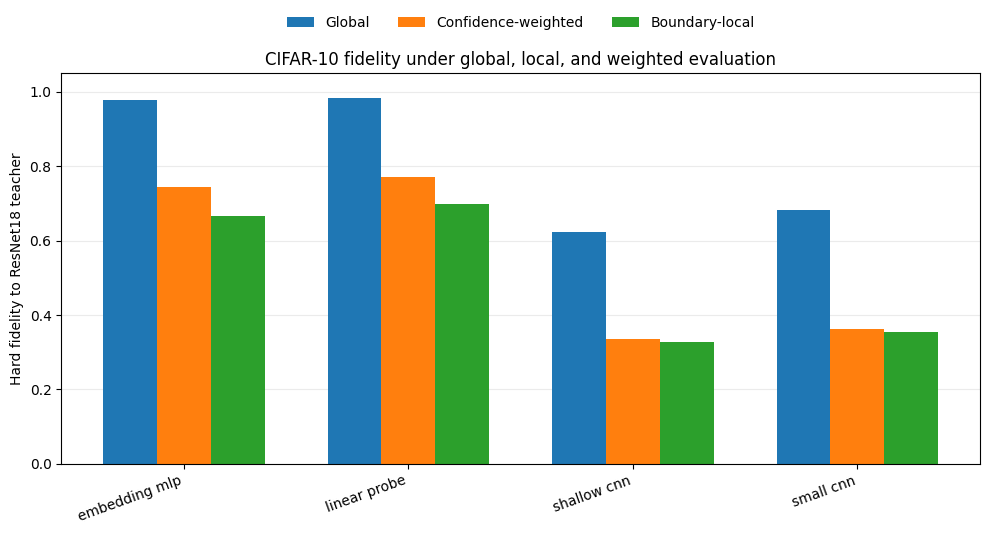

In [28]:
# -----------------------------------------------------------------------------
# Plot: CIFAR-10 global vs boundary-local vs confidence-weighted fidelity
# Required CSV:
#   cifar_fidelity_results.csv
# -----------------------------------------------------------------------------

cifar_results = require_csv("cifar_fidelity_results.csv")

surrogate_order = [
    "embedding_mlp",
    "linear_probe",
    "shallow_cnn",
    "small_cnn",
]

surrogate_order = [
    s for s in surrogate_order
    if s in set(cifar_results["surrogate"])
]

plot_df = (
    cifar_results
    .set_index("surrogate")
    .loc[surrogate_order]
    .reset_index()
)

positions = np.arange(len(plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax.set_facecolor("white")

metric_specs = [
    ("global_fidelity", "Global"),
    ("confidence_weighted_fidelity", "Confidence-weighted"),
    ("boundary_fidelity", "Boundary-local"),
]

offsets = [-width, 0, width]

for (col, label), offset in zip(metric_specs, offsets):
    ax.bar(
        positions + offset,
        plot_df[col],
        width,
        label=label,
    )

ax.set_xticks(positions)
ax.set_xticklabels(
    [s.replace("_", " ") for s in plot_df["surrogate"]],
    rotation=20,
    ha="right",
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Hard fidelity to ResNet18 teacher")
ax.set_title("CIFAR-10 fidelity under global, local, and weighted evaluation")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=False,
)

fig.tight_layout()

plt.savefig(
    "cifar_global_boundary_confidence_weighted.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### CIFAR-10 Confidence-Stratified Fidelity

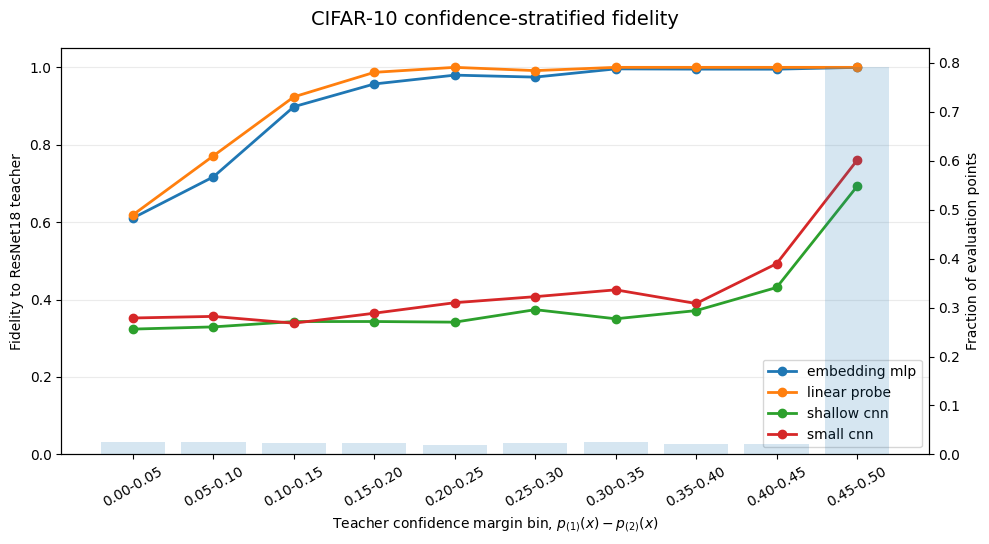

In [29]:
# -----------------------------------------------------------------------------
# Plot: CIFAR-10 confidence-stratified fidelity
# Required CSV:
#   cifar_confidence_bins.csv
# -----------------------------------------------------------------------------

cifar_confidence_bins = require_csv("cifar_confidence_bins.csv")

surrogate_order = [
    "embedding_mlp",
    "linear_probe",
    "shallow_cnn",
    "small_cnn",
]

surrogate_order = [
    s for s in surrogate_order
    if s in set(cifar_confidence_bins["surrogate"])
]

fig, ax1 = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax1.set_facecolor("white")

for surrogate_name in surrogate_order:

    subset = (
        cifar_confidence_bins[
            cifar_confidence_bins["surrogate"] == surrogate_name
        ]
        .sort_values("bin_left")
    )

    ax1.plot(
        subset["bin"],
        subset["fidelity"],
        marker="o",
        linewidth=2,
        label=surrogate_name.replace("_", " "),
    )

fraction_subset = (
    cifar_confidence_bins
    .groupby("bin", as_index=False)
    .agg(
        bin_left=("bin_left", "first"),
        fraction=("fraction", "mean"),
    )
    .sort_values("bin_left")
)

ax2 = ax1.twinx()

ax2.bar(
    fraction_subset["bin"],
    fraction_subset["fraction"],
    alpha=0.18,
    width=0.8,
)

ax1.set_ylim(0, 1.05)
ax1.set_xlabel(r"Teacher confidence margin bin, $p_{(1)}(x)-p_{(2)}(x)$")
ax1.set_ylabel("Fidelity to ResNet18 teacher")
ax2.set_ylabel("Fraction of evaluation points")
ax1.tick_params(axis="x", rotation=30)

ax1.grid(axis="y", alpha=0.25)
ax1.set_axisbelow(True)

ax1.legend(
    loc="lower right",
    frameon=True,
)

fig.suptitle("CIFAR-10 confidence-stratified fidelity", fontsize=14)
fig.tight_layout()

plt.savefig(
    "cifar_confidence_stratified_fidelity.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### CIFAR-10 Surrogate Ranking Table

### Fidelity Evaluation

We now extract the predictions from both the teacher and the surrogate models to compute globally aggregated and locality-aware fidelity metrics.

In [30]:
# -----------------------------------------------------------------------------
# Table: CIFAR-10 surrogate ranking by evaluation metric
# Required CSV:
#   cifar_surrogate_selection_table.csv
# -----------------------------------------------------------------------------

cifar_selection = require_csv("cifar_surrogate_selection_table.csv")

selection_display = cifar_selection[[
    "surrogate",
    "global_fidelity",
    "confidence_weighted_fidelity",
    "boundary_fidelity",
    "rank_global",
    "rank_confidence_weighted",
    "rank_boundary",
]].copy()

selection_display["surrogate"] = (
    selection_display["surrogate"]
    .str.replace("_", " ")
)

selection_display = selection_display.sort_values("rank_global")
selection_display

,surrogate,global_fidelity,confidence_weighted_fidelity,boundary_fidelity,rank_global,rank_confidence_weighted,rank_boundary
0,linear probe,0.9825,0.771022,0.697211,1.0,1.0,1.0
1,embedding mlp,0.9785,0.745275,0.665339,2.0,2.0,2.0
2,small cnn,0.6825,0.363171,0.354582,3.0,3.0,3.0
3,shallow cnn,0.6221,0.335946,0.326693,4.0,4.0,4.0


### CIFAR-10 Confidence-Bin Summary

In [31]:
# -----------------------------------------------------------------------------
# Table: CIFAR-10 confidence-bin summary
# Required CSV:
#   cifar_confidence_bins_summary.csv
# -----------------------------------------------------------------------------

cifar_confidence_summary = require_csv(
    "cifar_confidence_bins_summary.csv"
)

cifar_confidence_summary

,bin,bin_left,bin_right,fidelity_mean,fidelity_std,fraction_mean,n_points_mean
0,0.00-0.05,0.00,0.05,0.476434,0.160182,0.0244,244.0
1,0.05-0.10,0.05,0.10,0.543605,0.232932,0.0258,258.0
2,0.10-0.15,0.10,0.15,0.626059,0.329209,0.0236,236.0
3,0.15-0.20,0.15,0.20,0.663090,0.357136,0.0233,233.0
4,0.20-0.25,0.20,0.25,0.678392,0.360434,0.0199,199.0
5,0.25-0.30,0.25,0.30,0.686975,0.342388,0.0238,238.0
6,0.30-0.35,0.30,0.35,0.692913,0.353645,0.0254,254.0
7,0.35-0.40,0.35,0.40,0.689220,0.356293,0.0218,218.0
8,0.40-0.45,0.40,0.45,0.729858,0.310224,0.0211,211.0
9,0.45-0.50,0.45,0.50,0.863131,0.160411,0.7909,7909.0


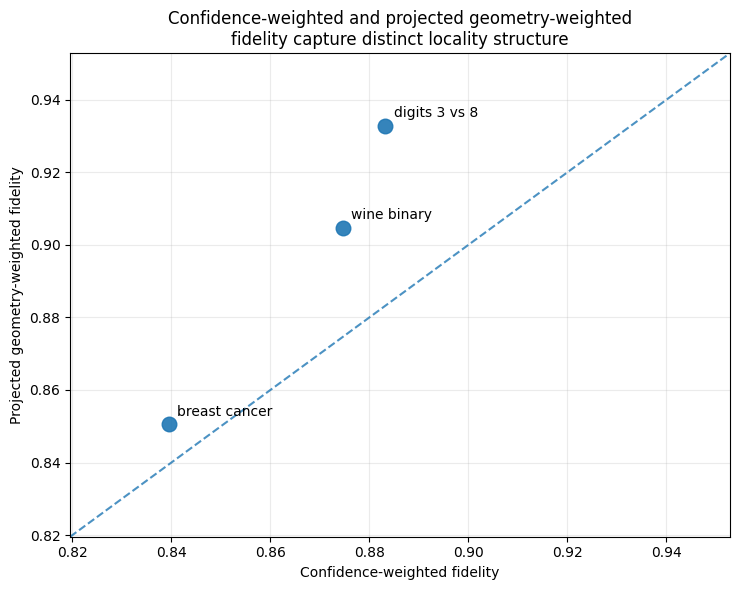

In [34]:
# -----------------------------------------------------------------------------
# Plot: confidence-weighted vs projected-geometry-weighted fidelity
# -----------------------------------------------------------------------------

summary = real_world_summary

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")
ax.set_facecolor("white")

x = summary["confidence_weighted_mean"]
y = summary["projected_geometry_weighted_mean"]

# Scatter points
ax.scatter(
    x,
    y,
    s=110,
    alpha=0.9,
)

# Dataset labels
for _, row in summary.iterrows():
    ax.annotate(
        row["dataset"].replace("_", " "),
        (
            row["confidence_weighted_mean"],
            row["projected_geometry_weighted_mean"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
    )

# Identity line
lo = min(x.min(), y.min()) - 0.02
hi = max(x.max(), y.max()) + 0.02

ax.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
)

# Axes
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

ax.set_xlabel("Confidence-weighted fidelity")
ax.set_ylabel("Projected geometry-weighted fidelity")

ax.set_title(
    "Confidence-weighted and projected geometry-weighted\n"
    "fidelity capture distinct locality structure"
)

# Light grid
ax.grid(alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "real_world_confidence_vs_projected_geometry.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

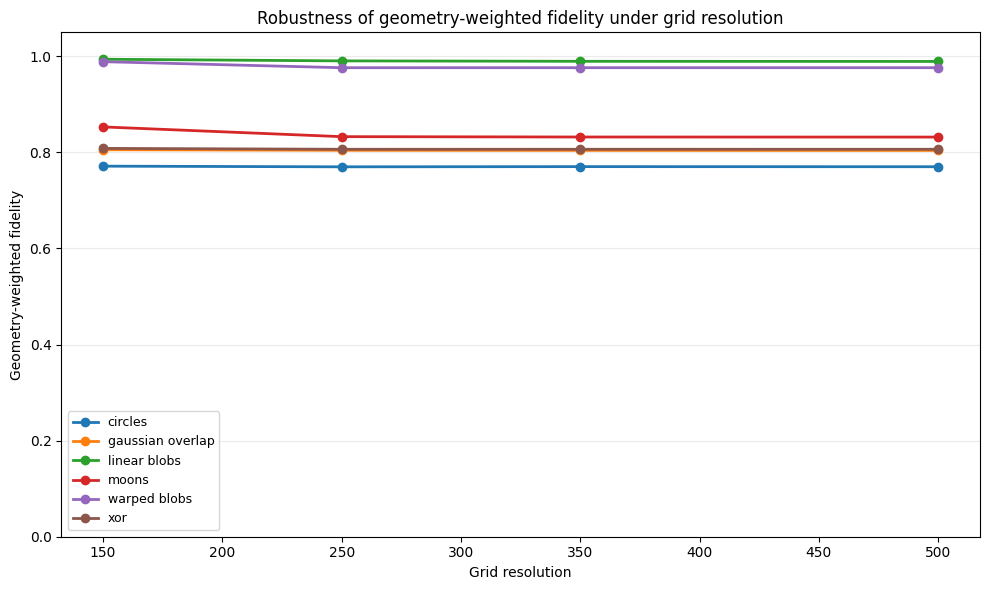

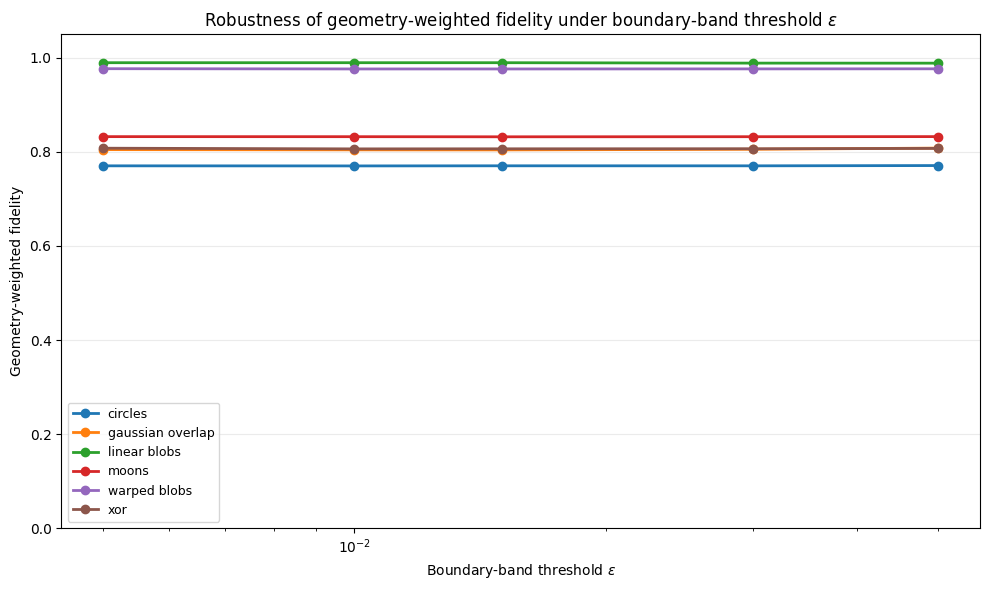

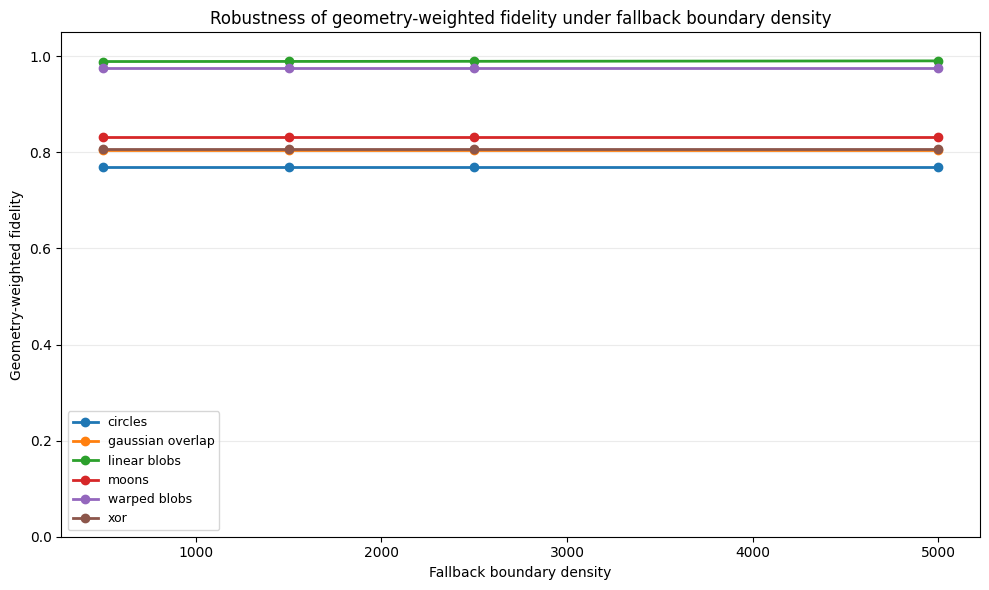

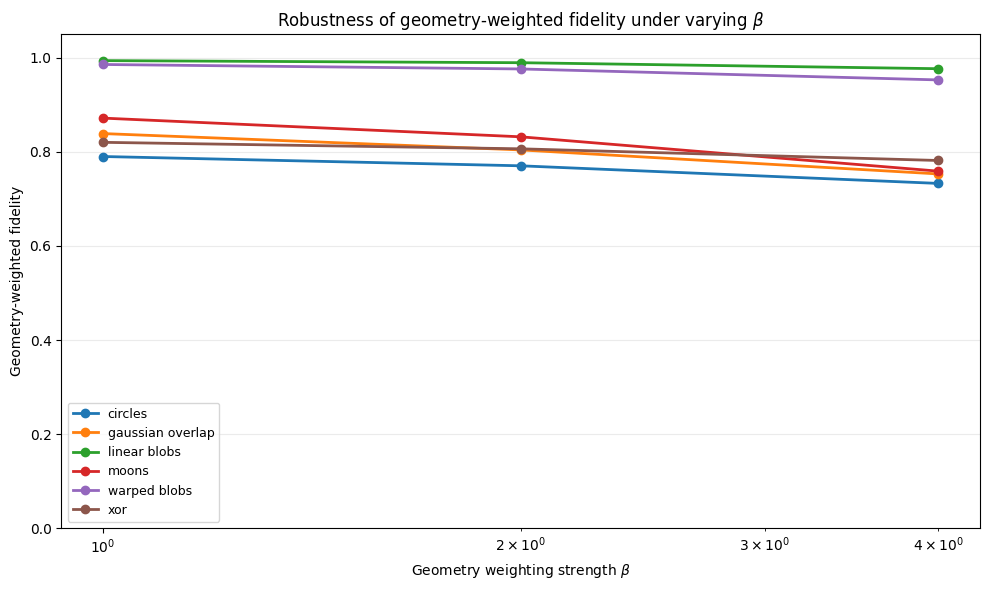

In [41]:
dataset_summary = require_csv("robustness_sweep_dataset_summary.csv")

# -----------------------------------------------------------------------------
# Dataset-level plots for geometry-weighted fidelity
# -----------------------------------------------------------------------------

pretty_names = {
    "grid_size": "Grid resolution",
    "band_eps": r"Boundary-band threshold $\varepsilon$",
    "fallback_k": "Fallback boundary density",
    "beta": r"Geometry weighting strength $\beta$",
}

pretty_titles = {
    "grid_size": "Robustness of geometry-weighted fidelity under grid resolution",
    "band_eps": r"Robustness of geometry-weighted fidelity under boundary-band threshold $\varepsilon$",
    "fallback_k": "Robustness of geometry-weighted fidelity under fallback boundary density",
    "beta": r"Robustness of geometry-weighted fidelity under varying $\beta$",
}

for sweep_type in ["grid_size", "band_eps", "fallback_k", "beta"]:
    subset = dataset_summary[dataset_summary["sweep_type"] == sweep_type].copy()

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    for dataset_name, group in subset.groupby("dataset"):
        group = group.sort_values("sweep_value")

        ax.plot(
            group["sweep_value"],
            group["geometry_weighted_mean"],
            marker="o",
            linewidth=2,
            label=dataset_name.replace("_", " "),
        )

    if sweep_type in ["band_eps", "beta"]:
        ax.set_xscale("log")

    # Optional horizontal reference lines for beta plot, if columns are available.
    # These make the main-paper beta sweep more interpretable.
    if sweep_type == "beta":
        reference_cols = [
            ("global_fidelity_mean", "Global fidelity"),
            ("confidence_weighted_mean", "Confidence-weighted fidelity"),
        ]

        for col, label in reference_cols:
            if col in subset.columns:
                reference_value = subset.groupby("dataset")[col].mean().mean()
                ax.axhline(
                    reference_value,
                    linestyle="--",
                    linewidth=1.5,
                    alpha=0.75,
                    label=label,
                )

    ax.set_ylim(0, 1.05)
    ax.set_xlabel(pretty_names[sweep_type])
    ax.set_ylabel("Geometry-weighted fidelity")
    ax.set_title(pretty_titles[sweep_type])

    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    ax.legend(
        loc="lower left",
        frameon=True,
        fontsize=9,
    )

    plt.tight_layout()

    plt.savefig(
        f"robustness_dataset_geometry_weighted_vs_{sweep_type}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()